### Day 9 - More Comparing distributions + Nonparametric modeling

Last time we looked at the K-S test which finds the maximum distance between two distributions. This gives a p-value relative to that and allows us to reject/not reject the null hypothesis depending on if the distributions are different/the same.

In [1]:
import numpy as np
from scipy import stats

np.random.seed(0)
vals = np.random.normal(loc=0, scale=1, size= 1000)

print(f'Normal: {stats.kstest(vals, "norm")}')
print(f'Uniform: {stats.kstest(vals, "uniform")}')

Normal: KstestResult(statistic=np.float64(0.03737519429804048), pvalue=np.float64(0.11930823166569182), statistic_location=np.float64(0.47224715008784873), statistic_sign=np.int8(1))
Uniform: KstestResult(statistic=np.float64(0.524), pvalue=np.float64(3.1089306676707934e-256), statistic_location=np.float64(-0.001385042735095726), statistic_sign=np.int8(1))


### The U test and Wilcoxon test (not in lecture)

The **U-test** is a nonparametric test for testing whether two data sets are drawn from distributions with different location parameters. It compares the ranks/medians of two independant groups and it can be used on non-gaussian distributions. This is different to the t-test which looks at the mean and requires continuous data and assumes a normal distribution.

How to use it?
1. Combine all observations from both samples and sort them while retaining the information about which data set a value came from.
2. For every observation in sample 1, count how many observations in sample 2 that have a smaller rank (value)
3. Sum up these counts to get $U_1$
4. Reversing this gets $U_2$

However, as we have seen before for the KS test yesterday, for larger samples (more than 20), U can be calculated directly using:

$$U_1 = R_1 - \frac{N_1(N_1-1)}{2}$$

Where $R_1$ is the sum of ranks for sample 1 and analagous for sample 2. The U statistic we use is the smaller of the two we calculate so, $U = min(U_1, U_2)$

For this case, we can approximate the behaviour for $U$ as Gaussian, $\mathcal{N}(\mu_U,\sigma_U)$

Where,

$$\mu_U = \frac{N_1N_2}{2} \qquad \qquad \sigma_U = \sqrt{\frac{N_1N_2(N_1+N_2+1)}{12}}. $$

And the z score is calculated as:

$$z = \frac{U-\mu_U}{\sigma_U}$$


The **Wilcoxon signed-rank test** can be used to compare the means of two arbitrary distributions.

It is based on the differences, $y_i=x_{1,i}-x_{2,i}$, where the values with $y_i = 0$ are excluded.

1. So we compute $|y_1,...,|y_n||$
2. Sort these values to assign ranks
3. Each par is assigned $\Phi = 1$ if $x_{1,i} > x_{2,i}$ and 0 otherwise.
4. The statistic becomes

$$W_+ = \sum^m_i \Phi_iR_i$$

So all the ranks with $y_i > 0$ are summed while $W_-$ would be all the ranks with $y_i <0$. The statistic T is the smaller of the two.

As before, for m larger than 20, we can assume a gaussian distribution such that 

$$\mu_T = \frac{N(2N+1)}{2} \qquad \qquad \sigma_T = N \sqrt{\frac{(2N+1)}{12}}.$$

And 

$$z = \frac{T-\mu_T}{\sigma_T}$$

Now lets implement the tests:

In [2]:
import numpy as np
from scipy import stats
np.random.seed(0)

x, y = np.random.normal(0, 1, size=(2, 1000))
print(stats.mannwhitneyu(x, y))

MannwhitneyuResult(statistic=np.float64(482654.0), pvalue=np.float64(0.17919398705643008))


In [3]:
import numpy as np
from scipy import stats
np.random.seed(0)

x = np.random.normal(-1, 1, 200)
y = np.random.normal(-0.5, 1.5, 300) # same shape but different location and scale parameters

print(stats.ranksums(x, y))

x = np.random.normal(0, 1, 500)
y = np.random.uniform(-0.5, 0.5, 500) # different shapes, same location

print(stats.ranksums(x, y))

RanksumsResult(statistic=np.float64(-2.6435517147698615), pvalue=np.float64(0.008204123191145227))
RanksumsResult(statistic=np.float64(-2.1280433697217225), pvalue=np.float64(0.03333348790392057))


Wilcoxon test:

In [4]:
import numpy as np
from scipy import stats
np.random.seed(0)

x, y = np.random.normal(0, 1, size=(2, 1000))
print(stats.wilcoxon(x, y))

a = np.random.normal(0, 1, size=500)
b = np.random.uniform(0, 1, size=500)

print(stats.wilcoxon(a, b))

WilcoxonResult(statistic=np.float64(238373.0), pvalue=np.float64(0.19357179019702442))
WilcoxonResult(statistic=np.float64(29627.0), pvalue=np.float64(1.8119410593156403e-24))


### What if my distributions are two dimensional?

We can use the following method
1. Assume we have two sets of two-dimensional data points: $\{x_i^A, y_i^A\}$ for $i = 1, \dots, N_A$, and $\{x_i^B, y_i^B\}$ for $i = 1, \dots, N_B$. Define four quadrants centered on a specific reference point $\{x_j^A, y_j^A\}$:
$$Q_1: (x > x_j^A, y > y_j^A)$$
$$Q_2: (x \le x_j^A, y > y_j^A)$$
$$Q_3: (x \le x_j^A, y \le y_j^A)$$
$$Q_4: (x > x_j^A, y \le y_j^A)$$

2. Compute the fraction of data points from sample $A$ and sample $B$ that fall into each of the four quadrants:
$$f_k^A = \frac{1}{N_A} \sum_{i=1}^{N_A} \mathbb{I}\left(\{x_i^A, y_i^A\} \in Q_k\right), \quad k = 1, 2, 3, 4$$
$$f_k^B = \frac{1}{N_B} \sum_{i=1}^{N_B} \mathbb{I}\left(\{x_i^B, y_i^B\} \in Q_k\right), \quad k = 1, 2, 3, 4$$

Where $\mathbb{I}$ is the indicator function that evaluates to 1 if the condition within is true. It checks whether data point i from sample A falls inside quadrant k.

3. Record the maximum absolute difference among the four quadrants between the fractions for sample $A$ and sample $B$ relative to point $j$:
$$d_j^A = \max_{k \in \{1, 2, 3, 4\}} \left| f_k^A - f_k^B \right|$$

4. Repeat steps 1–3 for all data points $\{x_j^A, y_j^A\}$ in sample $A$ to obtain the overall maximum difference $D_A$, repeat the entire process using all points in sample $B$ as origins to obtain $D_B$, and compute the overall test statistic $D$:
$$D_A = \max_{j = 1, \dots, N_A} \left( d_j^A \right)$$
$$D_B = \max_{j = 1, \dots, N_B} \left( d_j^B \right)$$
$$D = \frac{D_A + D_B}{2}$$

Then we can calculate the effective sample size $n_e$ and the correlation coefficient $\rho$, then compute the scaled argument $\lambda$:
$$n_e = \frac{N_A N_B}{N_A + N_B}$$
$$\lambda = \frac{\sqrt{n_e} \, D}{1 + \left(0.25 - \frac{0.75}{\sqrt{n_e}}\right) \sqrt{1 - \rho^2}}$$

For $n_e > 20$, evaluate the significance level ( $p$-value) of statistic $D$ using the asymptotic cumulative distribution function:
$$Q_{KS}(\lambda) = 2 \sum_{k=1}^{\infty} (-1)^{k-1} e^{-2 k^2 \lambda^2}$$

The rest of the discussion about other tests I will deepdive into later.

### Non parametric modeling and Histograms

Nonparametric modeling is used when we don't assume a predefined shape of the distribution. Hence when we dont have strong assumptions, this can reduce bias.

Since it is so flexible, nonparametric models can overfit the data and not be able to make further predictions as well.

- Histograms are a parametric method used to analyze 1D data sets. It divided data into bins and assumes a constant density value in each bin. The value estimated in each bin counts as the parameter.

There is specified distribution class, but instead a general set of distribution free models called **Sobolev Space**

This just enforces basic smoothness constraints:

$$\int [h^{\prime\prime}(x)]^2dx < \infty .$$

This prevents infinite spikes while allowing the model to adapt to any complex underlying distribution as the sample grows

Lets look at histograms first:

In [11]:
np.random.seed(0)
N = 1000
mu_gamma_f = [(5, 1.0, 0.1),
              (7, 0.5, 0.5),
              (9, 0.1, 0.1),
              (12, 0.5, 0.2),
              (14, 1.0, 0.1)]
true_pdf = lambda x: sum([f* stats.cauchy(mu,gamma).pdf(x) for mu,gamma,f in mu_gamma_f])

x = np.concatenate([stats.cauchy(mu, gamma).rvs(int(f*N)) for mu,gamma,f in mu_gamma_f])

np.random.shuffle(x)
x = x[x > -10]
x = x[x < 30]

Thats the generation of the data, now lets plot it and see what happens when we use more bins:

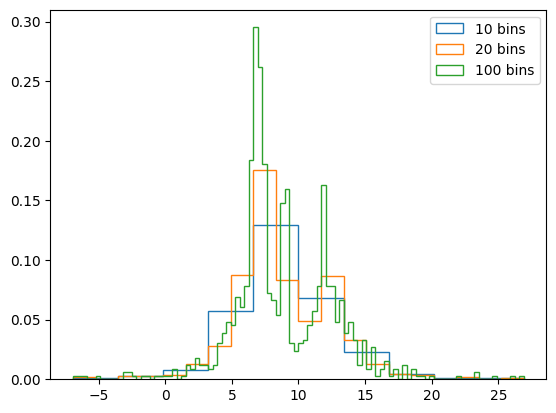

In [17]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots()

ax.hist(x, bins = 10, histtype= "step", density = True, label = "10 bins")
ax.hist(x, bins = 20, histtype= "step", density = True, label = "20 bins")
ax.hist(x, bins = 100, histtype= "step", density = True, label = "100 bins")
ax.legend()

It starts off looking quite unimodal and gaussian, but with small changes in the parameters of the histogram, it changes the PDF significantly.

This is because we are doing several things
1. Some bins end up with little to no data
2. We are moving the data to the centre of each bin, which is bad as we are changing data
3. We are modelling a pdf with non differentiable, step like functions which is very artificial

So lets make variable width bin sizes that have the same number of objects in each bin.

In [18]:
bins100 = np.append(np.sort(x)[::100], np.max(x))  # This gives a bin with 100 objects in each bin
bins30 = np.append(np.sort(x)[::30], np.max(x))
print(len(bins100),len(bins30))

11 34


(array([0.00325321, 0.01638671, 0.04200008, 0.06372276, 0.05673795,
        0.10494417, 0.21370459, 0.26828345, 0.21138804, 0.35027655,
        0.32725515, 0.2619256 , 0.28523646, 0.25665559, 0.27797771,
        0.11749238, 0.06802251, 0.05824576, 0.10575226, 0.45074583,
        0.20493048, 0.03376087, 0.03608575, 0.06202438, 0.08336727,
        0.17172474, 0.13088222, 0.07417871, 0.04868107, 0.05084424,
        0.03266814, 0.01529497, 0.00210787]),
 array([-6.92142972,  2.478838  ,  4.34504744,  5.07316606,  5.55307373,
         6.09206116,  6.3834641 ,  6.52656369,  6.64055148,  6.78521927,
         6.87252468,  6.96597177,  7.08272645,  7.18993939,  7.30909144,
         7.419104  ,  7.67938504,  8.12895737,  8.65399202,  8.94316824,
         9.01101366,  9.16024007, 10.06605315, 10.9135079 , 11.40655656,
        11.77337966, 11.9514614 , 12.18511452, 12.59737621, 13.22556784,
        13.82703299, 14.76314508, 16.76256345, 26.91818424]),
 [<matplotlib.patches.Polygon at 0x23de2bcbcd0

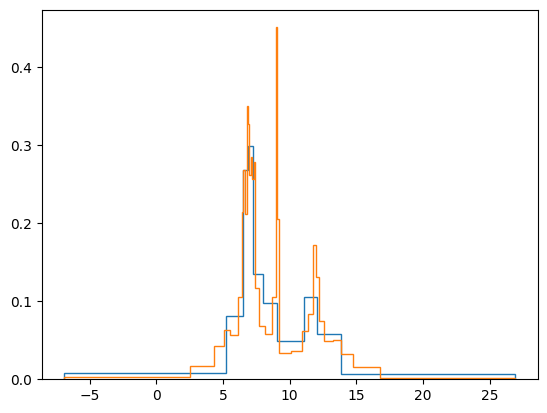

In [19]:
plt.hist(x, bins = bins100, density = True, histtype= "step")
plt.hist(x, bins = bins30, density = True, histtype= "step")

This can of course look different depending on the number of objects you choose in each bin.

There is no right way of setting bin sizes but there are a few rules of thumb:

##### Scotts Rule

Scotts rule suggests that the optimal bin width is

$$\Delta_b = \frac{3.5\sigma}{N^{1/3}}.$$

This only makes sense if the distribution is close to gaussian, and $\sigma$ gives an ~description of the data

If not, then we use

$$\Delta_b = \frac{2(q_{75}-q_{25})}{N^{1/3}} = \frac{2.7\sigma_G}{N^{1/3}}.$$

So lets see these in action:

0.9917634055684971
36
[-6.92142972e+00 -5.92966631e+00 -4.93790291e+00 -3.94613950e+00
 -2.95437610e+00 -1.96261269e+00 -9.70849286e-01  2.09141194e-02
  1.01267752e+00  2.00444093e+00  2.99620434e+00  3.98796774e+00
  4.97973115e+00  5.97149455e+00  6.96325796e+00  7.95502136e+00
  8.94678477e+00  9.93854818e+00  1.09303116e+01  1.19220750e+01
  1.29138384e+01  1.39056018e+01  1.48973652e+01  1.58891286e+01
  1.68808920e+01  1.78726554e+01  1.88644188e+01  1.98561822e+01
  2.08479456e+01  2.18397090e+01  2.28314724e+01  2.38232359e+01
  2.48149993e+01  2.58067627e+01  2.67985261e+01  2.69181842e+01]


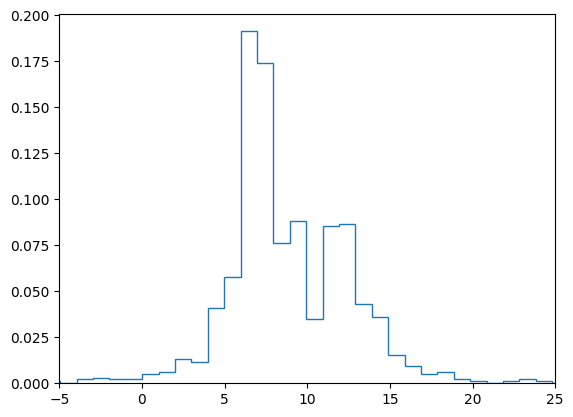

In [21]:
from astroML import stats as astroMLstats
sigmaG2 = astroMLstats.sigmaG(x)
binsize = 2.7*sigmaG2/(N**(1/3))
binsG = np.append(np.arange(start=x.min(), stop=x.max(), step=binsize) , x.max()) #Complete

print(binsize)
print(len(binsG))
print(binsG)

plt.hist(x, bins=binsG, density=True, histtype="step") #Complete
plt.xlim(-5,25);

We can also use a shortcut from astropy

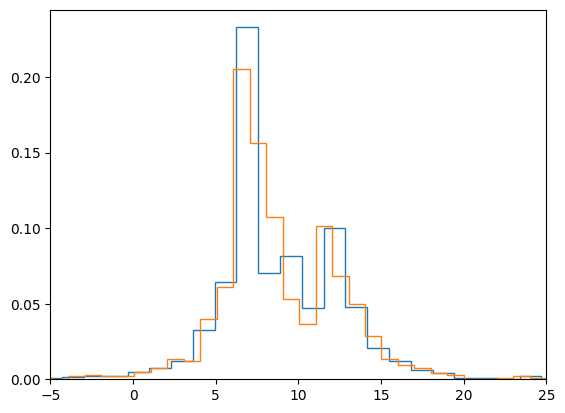

In [22]:
import astropy.visualization.hist
astropy.visualization.hist(x, bins="scott", histtype="step",density=True)
astropy.visualization.hist(x, bins="freedman", histtype="step",density=True)
plt.xlim(-5,25);

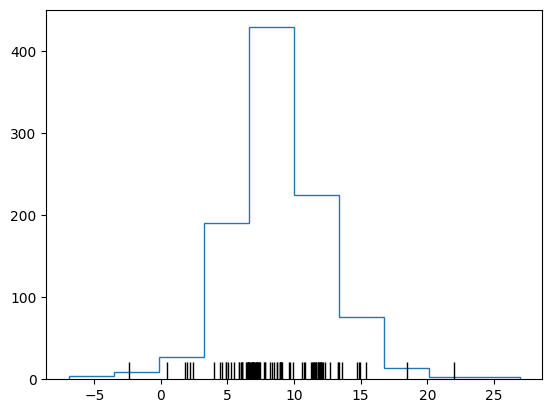

In [23]:
plt.hist(x,histtype="step")
plt.plot(x[:100], 0*x[:100], '|', color='k', markersize=25);

This is called a rug plot which has the small tick marks along the axis of the graph. It shows where every single data point lies and helps you see the gaps between data points

The disadvantage here is that we don't have the relative number of objects at each point.

#### So overall

The normalized bin height of a histogram can simply be understood as

$$f_k = \frac{n_k}{\Delta_b N}$$

Where k indexes the bin, $n_k$ is the occupancy number of the bin. $\Delta_s$ is the bin width and N is the total sample size.

If we want to assign uncertainties to each bin height, we can use:

$$\sigma_k = \frac{\sqrt{n_k}}{\Delta_b N}$$

But this assumes that binning is a counting experiment, hence poisson distributed

### Kernel density estimation.

We can do better than this. The idea is to represent each data point as a distribution rather than a delta function.

This means that the data stays exactly where it is.

For the kernel, the most common used distributions are the Gaussian kernel and the Epanechnikov kernel. A downside of the gaussian is that the tails are infinite so each point has a finite probability of being anywhere. However, Epanechnikov has truncated tails.

This makes us wonder how wide should we make our kernels? These widths are called bandwidths and is the most important part.



In [56]:
from sklearn.neighbors import KernelDensity
xgrid = np.linspace(x.min(),x.max(),1000)

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

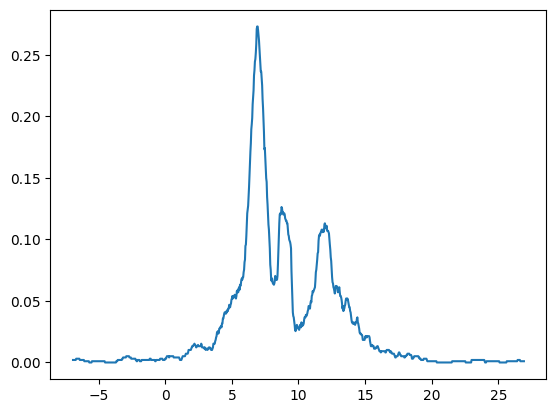

In [58]:
PDFtophat = kde_sklearn(x,bandwidth=0.5,kernel="tophat") 
plt.plot(xgrid,PDFtophat);

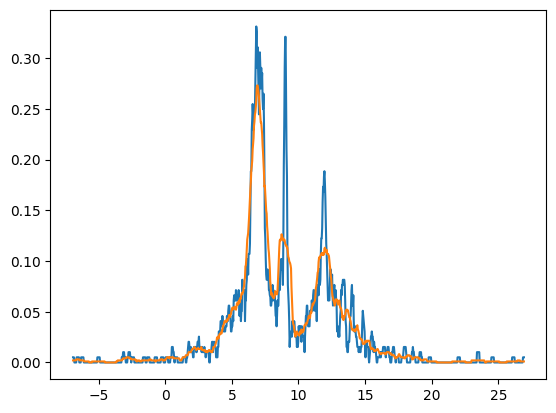

In [59]:
PDFtophat = kde_sklearn(x,bandwidth=0.1,kernel="tophat") 
plt.plot(xgrid,PDFtophat) 

PDFtophat = kde_sklearn(x,bandwidth=0.5,kernel="tophat") 
plt.plot(xgrid,PDFtophat);

As we change the bandwidth, there is less detail within the plot, but this can often be better

what about when we dont do a tophat style kernel, and instead a gaussian and epanechnikov one?

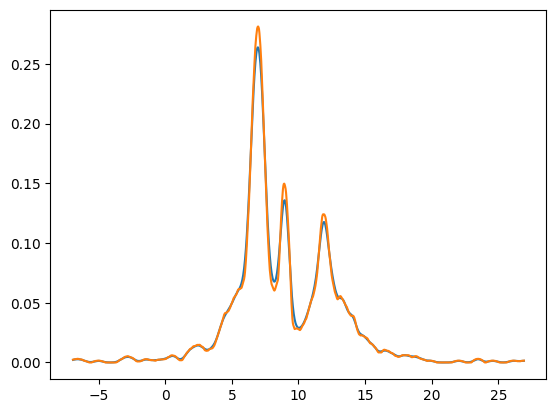

In [60]:
PDFtophat = kde_sklearn(x,bandwidth=0.3,kernel="gaussian")
plt.plot(xgrid,PDFtophat) 

PDFtophat = kde_sklearn(x,bandwidth=0.5,kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat) 

This is quite nice and we will see how to select the optimal bandwidth with cross validation next time.

#### This diverts now from the Lecture to the book/AstroML
#### Selection effects and luminosity function estimation

Now lets look at truncated and censored data, this can happen due to observational limits.

When the selection function $S(x)$ is known and finite, we can use it to correctly estimate the observed density $f(x)$ to get the true underlying distribution:

$$h(x) = \frac{f(x)}{S(x)}$$



Assume that in addition to $x$, we also measure a quantity $y$, and that our selection function is such that $S(x) = 1$ for $0 \le y \le y_{\text{max}}(x)$, and $S(x) = 0$ for $y > y_{\text{max}}(x)$, with $x_{\text{min}} \le x \le x_{\text{max}}$. Here, the observable $y$ may or may not be related to observable $x$, and the $y \ge 0$ assumption is added for simplicity and without a loss of generality.

We can think of x as the absolute magnitude and y as distance or redshift.

For this example we can compute something like:

$$y_\text{max}(x) = (x/(4\pi F_\text{min}))^{1/2}$$

Where $F_min$ is the smallest flux that our measuring appratus can detect.

Text(0, 0.5, '$y$')

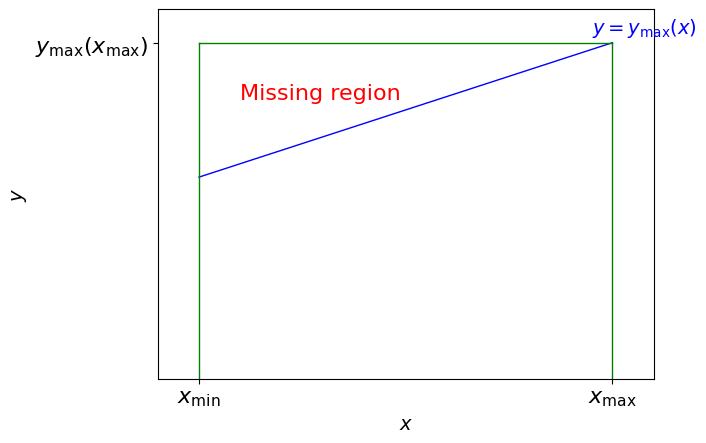

In [31]:
import numpy as np

fig = plt.Figure(figsize = (8,4))
max_func = lambda t: 0.4*t + 0.6
x = np.linspace(0,1,100)
ymax = max_func(x)

ymax[ymax>1] = 1

# plot func and lines
plt.plot(x, ymax, 'b', lw=1)
plt.plot([0, 1], [1, 1], 'g', lw=1)
plt.plot([1, 1], [0, 1], 'g', lw=1)
plt.plot([0, 0], [0, 1], 'g', lw=1)

# add text
plt.text(0.95, 1.03, r'$y = y_{\rm max}(x)$',color = 'b',fontsize = 14)
plt.text(0.1, 0.85, r'Missing region', color = 'r', ha='left', va='center', fontsize = 16)

# adjust the limits
plt.xlim(-0.1, 1.1)
plt.ylim(0, 1.1)
plt.xticks([0,1],[r'$x_{\rm min}$',r'$x_{\rm max}$'],fontsize = 16)
plt.yticks([1],[r'$y_{\rm max}(x_{\rm max})$'],fontsize = 16)
plt.xlabel('$x$', fontsize = 14)
plt.ylabel('$y$', fontsize = 14)

The blue boundary shows the maximum distance at which an objet with intrinsic property x can still be detected given the instruments minimum sensitivity threshold.

The missing region are the points that exist inr eality but are unobserved.

So how do we express the true distribution vs the observed distribution due to this missing region?

If there was no observational cutoff, $S(x) = 1$, then:

$$h(x) = \int^{y_\text{max}(x_\text{max})}_0 n(x,y) \: dy$$

Where $n(x,y)$ is the probability density.

For the observed distribution, we can only see up to $y_{max}(x)$ hence, 

$$f(x) = \int^{y_\text{max}(x)}_{0} n(x,y) \: dy$$

Now theres a slight challenge here, the difference between $f(x)$ and $h(x)$ depends heavily on how $n(x,y)$ behaves. Hence to recover h(x) we need to first estimate n(x,y).

Hence, 
1. Given a set of measured pairs $(x_i, y_i)$ and a known relation $y_{max}(x)$ estimate the 2D distribution n(x,y) from which the sample was drawn
2. Assume that the measurement errors for both x and y are negligible compared to their observed ranges, that x is measured within x_min and x_max. And that the selection function is 1 between $0 \leq y \leq y_\text{max}(x)$ and $x_\text{min} \leq x \leq x_\text{max}$ and 0 otherwise.